# 第二章
## Exercises
### 2.1

生成一个由**不相关的高斯随机数**组成的样本 $\{x_n\}$。你可以使用某个软件包中的例程（例如 Press 等人 (1992) 的 *Numerical Recipes*），或者 TISEAN 软件包中的 `makenoise` 例程。现在对这组数据应用**移动平均滤波器**

$$
s_n = \frac{1}{15}\sum_{j=-7}^{7} x_{n+j}
$$

从而得到 1024 个**相关的高斯变量**。从某个软件包（例如 TISEAN）中获取一个用于估计数据集**功率谱**的例程，并将其分别应用于序列 $\{x_n\}$ 和 $\{s_n\}$。你观察到了什么差异？

---

### 补充说明（帮助理解）

这段文字描述了一个典型的信号处理小实验：

1. **原始序列 $\{x_n\}$**：白噪声（不相关、高斯分布），其理论功率谱在所有频率上是**平坦的**（常数）。
2. **滤波后序列 $\{s_n\}$**：经过宽度为 15 的滑动平均（低通滤波）后，相邻点之间产生了相关性，高频成分被抑制。
3. **预期观察到的差异**：
   - $\{x_n\}$ 的功率谱大致是**水平的**（白噪声特征）。
   - $\{s_n\}$ 的功率谱会在**低频处较高**，向高频方向**衰减/下降**（因为移动平均起到了平滑作用，削弱了快速波动）。

In [ ]:
"""
makenoise_experiment.py
Generate white Gaussian noise, apply a 15-point moving average,
and compare their power spectra using Welch's method.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
N = 1024                # number of samples
SIGMA = 1.0             # standard deviation of white noise
WINDOW = 15             # moving average window size
FS = 1.0                # sampling frequency (normalized)
SEED = 42

rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Step 1: Generate white Gaussian noise {x_n}
# Equivalent to: makenoise -0 -g -r SIGMA -l N
# ------------------------------------------------------------
x = rng.normal(loc=0.0, scale=SIGMA, size=N)

# ------------------------------------------------------------
# Step 2: Apply 15-point moving average
# s_n = (1/WINDOW) * sum_{j=-7}^{7} x_{n+j}
# ------------------------------------------------------------
window = np.ones(WINDOW) / WINDOW
s = np.convolve(x, window, mode='same')

# ------------------------------------------------------------
# Step 3: Estimate power spectra using Welch's method
# ------------------------------------------------------------
nperseg = N // 4
f_x, Pxx_x = welch(x, fs=FS, nperseg=nperseg, noverlap=nperseg//2)
f_s, Pxx_s = welch(s, fs=FS, nperseg=nperseg, noverlap=nperseg//2)

# Theoretical transfer function of a moving average filter
H2 = np.abs(np.sinc(f_x * WINDOW))**2

# ------------------------------------------------------------
# Print summary statistics
# ------------------------------------------------------------
var_x = np.var(x)
var_s = np.var(s)
mean_Pxx_x = np.mean(Pxx_x)
mean_Pxx_s = np.mean(Pxx_s)

print(f"White noise x : mean={np.mean(x):.4f}, var={var_x:.4f} (theory=1.0)")
print(f"Filtered s    : mean={np.mean(s):.4f}, var={var_s:.4f} "
      f"(theory={SIGMA**2/WINDOW:.4f})")
print(f"Mean PSD (white noise) : {mean_Pxx_x:.4f}")
print(f"Mean PSD (filtered)    : {mean_Pxx_s:.4f}")

idx_quarter = np.argmin(np.abs(f_x - 0.25))
attenuation = Pxx_s[idx_quarter] / Pxx_x[idx_quarter]
print(f"PSD attenuation at f=0.25 : {attenuation:.3f}")

# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------
plt.figure(figsize=(8, 8))

# Time domain
plt.subplot(3, 1, 1)
plt.plot(x, label='White noise $x_n$', alpha=0.7)
plt.plot(s, label=f'{WINDOW}-point moving average $s_n$', alpha=0.9)
plt.xlabel('Sample index $n$')
plt.ylabel('Amplitude')
plt.title('Time Series: White Noise vs. Filtered Signal')
plt.legend()
plt.grid(True, alpha=0.3)

# Power spectrum (log scale)
plt.subplot(3, 1, 2)
plt.semilogy(f_x, Pxx_x, label='$S^{(x)}(f)$ (white noise)', alpha=0.8)
plt.semilogy(f_s, Pxx_s, label=f'$S^{(s)}(f)$ (filtered)', alpha=0.8)
plt.plot(f_x, H2 * mean_Pxx_x, 'g--',
         label='Theoretical $|H(f)|^2$ (scaled)', alpha=0.7)
plt.xlabel('Frequency $f$')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectrum (Log Scale)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

# Low-frequency zoom (linear scale)
plt.subplot(3, 1, 3)
plt.plot(f_x, Pxx_x, label='$S^{(x)}(f)$', alpha=0.8)
plt.plot(f_s, Pxx_s, label=f'$S^{(s)}(f)$', alpha=0.8)
plt.xlim(0, 0.2)
plt.xlabel('Frequency $f$')
plt.ylabel('Power Spectral Density')
plt.title('Low-Frequency Region (Linear Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/images/makenoise_spectrum_compare.png', dpi=150)
plt.show()

### 2.2
创建两个人工时间序列。第一个序列 $\{\eta_n,\ n=1,\ldots,4096\}$ 包含在区间 $[0, 1]$ 内均匀分布的随机数（使用你喜欢的随机数生成器）。第二个序列 $\{s_n,\ n=1,\ldots,4096\}$ 基于 $x_n$ 的确定性演化，其遵循规则 $x_0 = 0.1$ 且 $x_{n+1} = 1 - 2x_n^2$（即 **Ulam 映射**，是**逻辑方程**的一个特例）。$x_n$ 的值不是被直接测量的，而是通过非线性观测函数 $s_n = \arccos(-x_n)/\pi$ 得到的。比较这两个时间序列的均值、方差和功率谱。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------- Parameter Settings ----------------------
N = 4096        # Time series length as required by exercise
x0 = 0.1        # Initial condition for the Ulam map

# 1. Generate uniformly distributed random sequence eta_n over [0,1]
np.random.seed(42)   # Fix random seed for reproducibility
eta = np.random.rand(N)

# 2. Generate Ulam map: x_{n+1}=1-2*x_n^2, then apply observation s_n = arccos(-x_n)/pi
x = np.zeros(N)
x[0] = x0
for n in range(N - 1):
    x[n + 1] = 1 - 2 * (x[n] ** 2)

s = np.arccos(-x) / np.pi   # Non‑linear observation function


# ---------------------- Compute Mean and Variance ----------------------
print("===== Statistics Comparison =====")
print(f"True uniform random eta: mean = {np.mean(eta):.4f}, variance = {np.var(eta):.4f}")
print(f"Ulam chaotic sequence s:   mean = {np.mean(s):.4f}, variance = {np.var(s):.4f}")


# ---------------------- Power Spectrum via FFT ----------------------
def power_spectrum(series):
    n = len(series)
    fft_vals = np.fft.fft(series)
    ps = np.abs(fft_vals) ** 2 / n      # Normalized power spectrum
    freqs = np.fft.fftfreq(n)
    # Keep only positive frequencies
    mask = freqs >= 0
    return freqs[mask], ps[mask]

def power_spectrum_welch(series, fs=1):
    f, Pxx = welch(series, fs=fs, nperseg=512, noverlap=256)
    return f, Pxx

freq_eta, ps_eta = power_spectrum(eta)
freq_s, ps_s = power_spectrum(s)

freq_eta_welch, ps_eta_welch = power_spectrum_welch(eta)
freq_s_welch, ps_s_welch = power_spectrum_welch(s)


# ---------------------- Plot Figures ----------------------
plt.figure(figsize=(14, 9))

# Subplot 1: Time series of eta
plt.subplot(5, 1, 1)
plt.plot(eta, label=r'$\eta_n$ true uniform random', color='#1f77b4')
plt.title('Time-series Comparison')
plt.ylabel(r'$\eta_n$')
plt.legend()
plt.xlim(0, 200)       # Show first 200 samples for visualization

# Subplot 2: Time series of s_n
plt.subplot(5, 1, 2)
plt.plot(s, label=r'$s_n$ Ulam-map chaotic sequence', color='#ff7f0e')
plt.ylabel(r'$s_n$')
plt.legend()
plt.xlim(0, 200)

# Subplot3: Overlaid power spectra
plt.subplot(5, 1, 3)
plt.plot(freq_eta[1:1025], ps_eta[1:1025], alpha=0.7, label=r'PSD $\eta_n$', color='#1f77b4')
plt.plot(freq_s[1:1025], ps_s[1:1025], alpha=0.7, label=r'PSD $s_n$', color='#ff7f0e')
plt.xlabel("Normalized Frequency")
plt.ylabel("Power Spectrum")
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(freq_eta_welch, ps_eta_welch, alpha=0.7, label=r'PSD $\eta_n$', color='#1f77b4')
plt.plot(freq_s_welch, ps_s_welch, alpha=0.7, label=r'PSD $s_n$', color='#ff7f0e')
plt.xlabel("Normalized Frequency")
plt.ylabel("Power Spectrum")
plt.legend()

plt.subplot(5, 1, 5)
plt.semilogy(freq_eta_welch, ps_eta_welch, label=r'PSD $\eta_n$', color="#1f77b4", linewidth=1.2)
plt.semilogy(freq_s_welch, ps_s_welch, label=r'PSD $s_n$', color="#ff7f0e", linewidth=1.2)
plt.xlabel("Normalized Frequency")
plt.ylabel("Power Spectrum (log scale)")
plt.title("Welch Power Spectral Density (Log-Y axis)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 第三章 Phase space methods
## Exercise
### 3.1
用不同的延迟时间 $\tau = 1, 2, \dots$（此处采样时间为 $\Delta t = 1$），绘制出来自 Hénon 映射（例 3.2）时间序列的不同二维相图。
哪一张图片提供了最清晰的信息？请用单位延迟（$\tau = 1$）的延迟坐标重写该映射。

(1) 哪一张图片提供了最清晰的信息？ (Which picture gives the clearest information?)<br>答案：$\tau = 1$（单位延迟）的相图提供了最清晰的信息。分析说明：当 $\tau = 1$ 时，相图展示一条光滑且连续的二次抛物线结构，没有交叠与混淆，直观反映了系统的低维确定性代数关系。当 $\tau \ge 2$ 时，由于非线性迭代的多次拉伸与折叠（Stretching and Folding）效应，原来清晰的抛物线结构被严重扭曲、打碎并散布在平面上，失去了简单直接的函数几何关系。<br>(2) 用单位延迟的延迟坐标重写映射 (Rewrite the map in delay coordinates with unit delay)<br>已知标准 Hénon 映射的二维状态方程为：$$x_{n+1} = 1 - a x_n^2 + y_n$$
$$y_{n+1} = b x_n$$由于 $y_n = b x_{n-1}$，将其直接代入第一个方程中，消去隐藏变量 $y_n$，可得到仅包含观测变量 $x$ 的单位延迟标量差分方程：$$x_{n+1} = 1 - a x_n^2 + b x_{n-1}$$如果写成二维延迟向量 $\mathbf{X}_n = \begin{pmatrix} x_n \\ x_{n-1} \end{pmatrix}$ 的相空间映射形式，则为：$$\mathbf{X}_{n+1} = \begin{pmatrix} x_{n+1} \\ x_n \end{pmatrix} = \begin{pmatrix} 1 - a x_n^2 + b x_{n-1} \\ x_n \end{pmatrix}$$这表明：单变量 $x$ 在二维延迟空间 $(x_{n-1}, x_n)$ 中的微分/拓扑结构与原始系统的状态空间 $(x_n, y_n)$ 完全同胚（等价），线性变换关系为 $y_n = b x_{n-1}$。

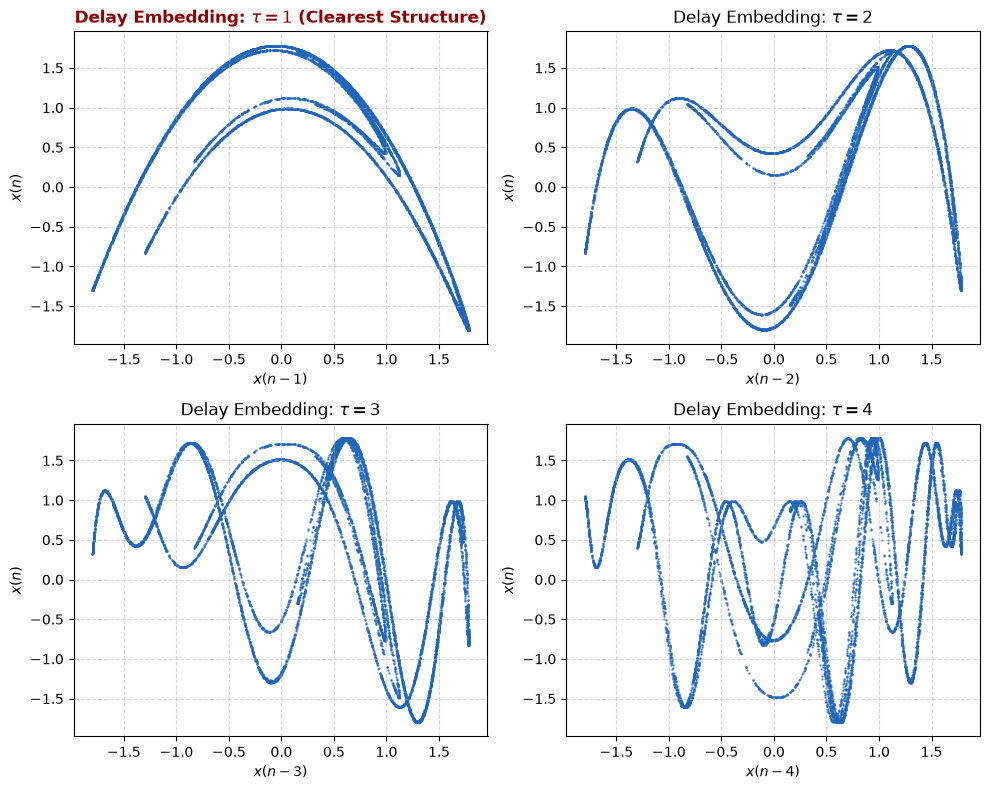

In [2]:
from nolitisea.data import henon_map
import matplotlib.pyplot as plt
# 1. 参数设置与数据生成
N = 10000
x_seq,_ = henon_map(n=N, a=1.4, b=0.3)

# 2. 绘制不同延迟时间 tau 下的相图
delays = [1, 2, 3, 4]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, tau in enumerate(delays):
    x_current = x_seq[tau:]
    x_delayed = x_seq[:-tau]

    ax = axes[i]
    # Increase point size and alpha to display sparse scattered points
    ax.scatter(x_delayed, x_current, s=0.5, c="#1f66bb", alpha=0.7)
    ax.set_title(f"Delay Embedding: $\\tau = {tau}$", fontsize=12)
    ax.set_xlabel(f"$x(n - {tau})$", fontsize=10)
    ax.set_ylabel("$x(n)$", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

    if tau == 1:
        ax.set_title(
            f"Delay Embedding: $\\tau = {tau}$ (Clearest Structure)",
            fontsize=12,
            color="darkred",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

### 3.2
通过对 Lorenz 系统 [Lorenz (1963)] 进行数值积分，生成一组流数据的标量时间序列：
$$\dot{x} = \sigma (y - x)$$
$$\dot{y} = r x - y - x z$$
$$\dot{z} = -b z + x y$$
参数设置为：$\sigma = 10$，$r = 28$，$b = 8/3$。该模型最初用于描述 Rayleigh–Bénard 型的热对流运动，其中：

$x$ 表示流体速度；

$y$ 表示上升流体与下降流体之间的温差；

$z$ 表示温度分布偏离线性状态的程度。（对于由相同方程控制的激光系统及实验数据，请参阅附录 B.1。）

具体要求与步骤：

1. 数值积分：使用积分器（例如小步长的龙格-库塔 Runge–Kutta 算法）进行求解。
2. 数据采样：设置合适的采样率，使得在吸引子的单叶（one leaf）上，轨迹每旋转一周平均记录约 25 个标量测量值（针对 $x$ 坐标）。
3. 相空间重构（Plot）：在不同的时间延迟 $\tau$ 下，绘制 $x$-坐标在二维延迟坐标系 $(x(t), x(t-\tau))$ 中的重构吸引子图像。
4. 直观观察与验证：通过目测观察验证——当延迟时间 $\tau$ 约为平均周期时间的 1/4（one-quarter of the mean cycle time）时，重构效果最佳。
5. 定量确认：计算自相关函数（Autocorrelation Function, ACF）和延迟互信息（Time Delayed Mutual Information, TDMI），以定量确认这一视觉印象。

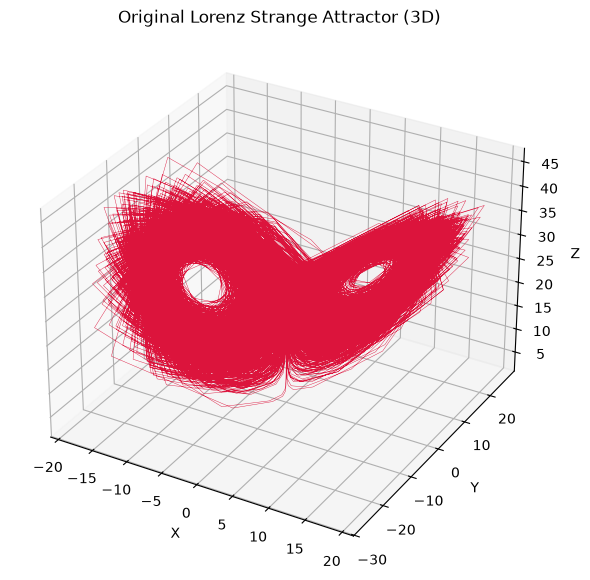

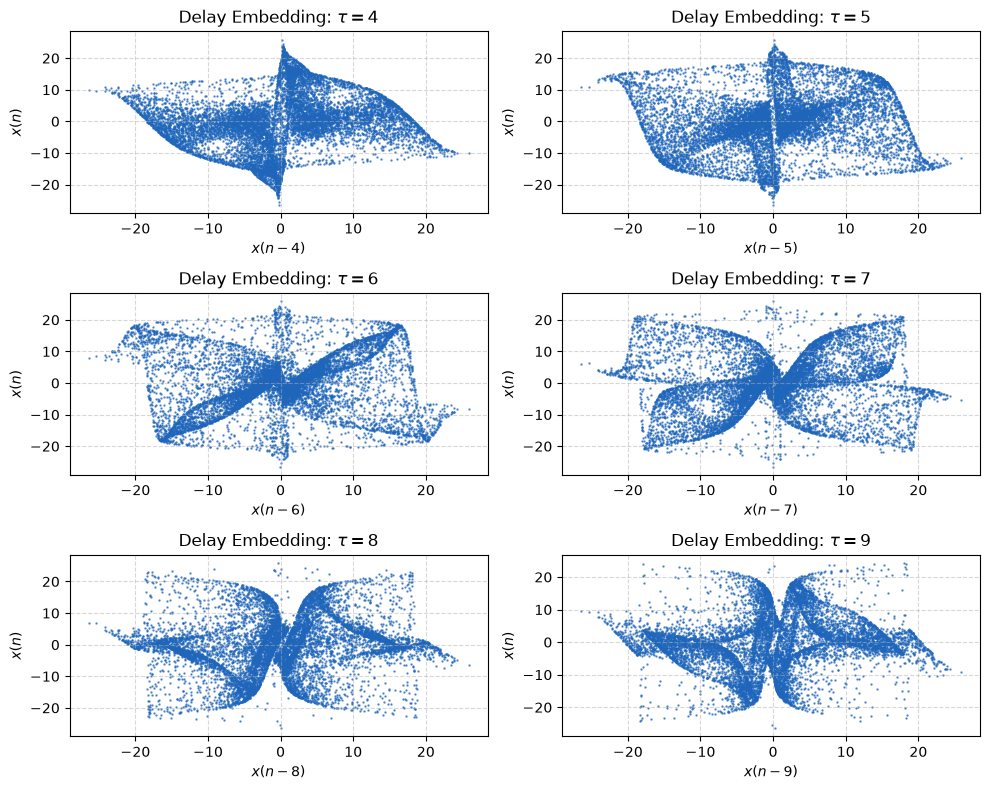

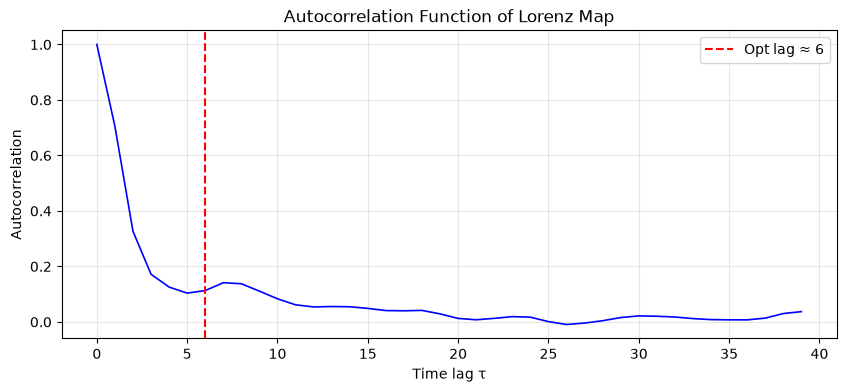

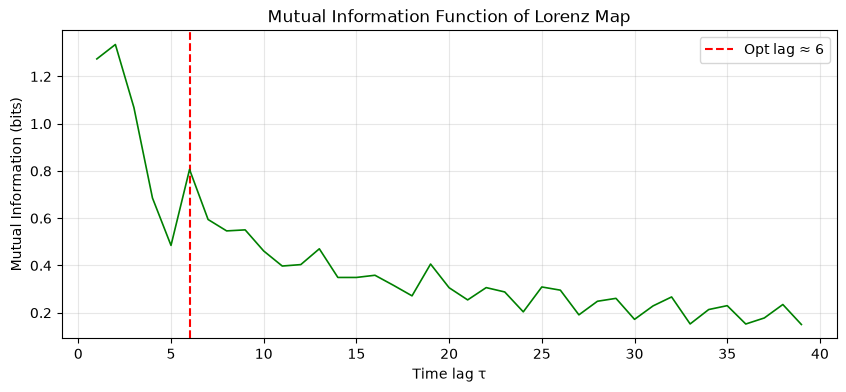

In [3]:
from nolitisea.data import lorenz_map
from nolitisea.delay import acorr, mutual_information
import numpy as np
import matplotlib.pyplot as plt

sample=0.128
_, x = lorenz_map(
    length   = 10000,       # 输出 10000 个采样点
    x0       = (1,1,1),         # 随机初始条件
    sigma    = 10.0,        # Lorenz σ
    beta     = 8.0 / 3.0,   # Lorenz b
    rho      = 28.0,        # Lorenz r
    step     = 0.01,       # 积分步长（不变）
    sample   = sample,       # ← 关键！dt = T/25 = 3.2/25
    discard  = 5000,        # 丢弃前 1000 个采样点
)

# 绘制3D轨迹图
fig3d = plt.figure(figsize=(8,7))
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.plot(x[:,0], x[:,1], x[:,2], lw=0.3, color='crimson')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Original Lorenz Strange Attractor (3D)')
plt.show()

# 绘制二维相图
best_lag=int(np.floor(3.2/4/sample))
x_seq=x[:,1]
delays = [best_lag-2,best_lag-1,best_lag,best_lag+1,best_lag+2,best_lag+3]
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, tau in enumerate(delays):
    x_current = x_seq[tau:]
    x_delayed = x_seq[:-tau]

    ax = axes[i]
    # Increase point size and alpha to display sparse scattered points
    ax.scatter(x_delayed, x_current, s=0.5, c="#1f66bb", alpha=0.7)
    ax.set_title(f"Delay Embedding: $\\tau = {tau}$", fontsize=12)
    ax.set_xlabel(f"$x(n - {tau})$", fontsize=10)
    ax.set_ylabel("$x(n)$", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

    if tau == 1:
        ax.set_title(
            f"Delay Embedding: $\\tau = {tau}$ (Clearest Structure)",
            fontsize=12,
            color="darkred",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

# 绘制自相关函数
ac_vals = acorr(x_seq, 40)
tau_axis = np.arange(0, 40)
plt.figure(figsize=(10,4))
plt.plot(tau_axis, ac_vals, 'b-', lw=1.2)
# 加上 标记最佳延迟时间的竖线
plt.axvline(x=best_lag, color='red', linestyle='--', label=f'Opt lag ≈ {best_lag}')
plt.xlabel('Time lag τ')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function of Lorenz Map')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 绘制互信息函数
max_tau_plot = 40
mi_vals = []
for tau in range(1, max_tau_plot):
    mi = mutual_information(x_seq[:-tau], x_seq[tau:], bins=30, normalize=False)
    mi_vals.append(mi)
plt.figure(figsize=(10,4))
# 加上 标记最佳延迟时间的竖线
plt.axvline(x=best_lag, color='red', linestyle='--', label=f'Opt lag ≈ {best_lag}')
plt.plot(tau_axis[1:], mi_vals, 'green', lw=1.2)
plt.xlabel('Time lag τ')
plt.ylabel('Mutual Information (bits)')
plt.title('Mutual Information Function of Lorenz Map')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 3.3


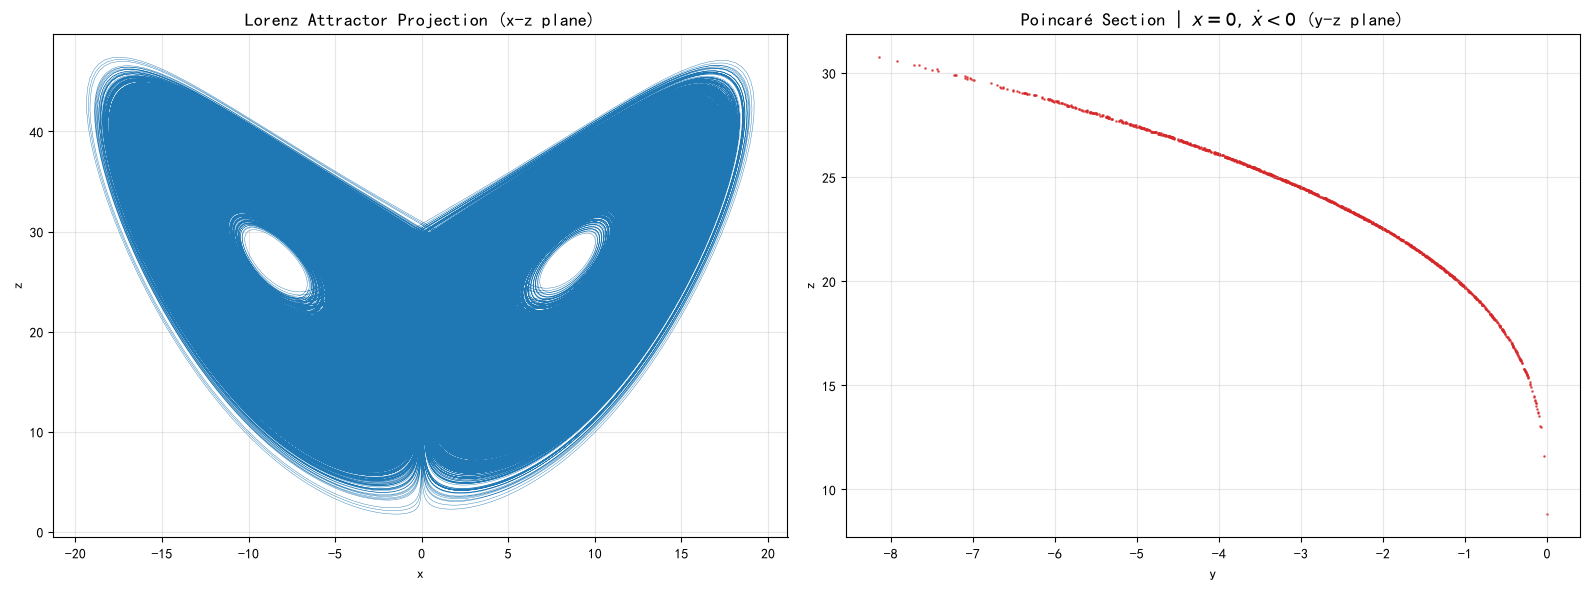

庞加莱截面采样总点数：1401


In [ ]:
import numpy as np
from nolitisea.data import lorenz_map
import matplotlib.pyplot as plt


# ====================== 2. 系统经典参数设置 ======================
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
# 初始状态
init_state = [1.0, 1.0, 1.0]
# 总积分时长
t_span = (0, 1000)
# 稠密时间采样点，方便捕捉穿越x=0时刻
t_eval = np.linspace(t_span[0], t_span[1], 2000000)

t_arr,x = lorenz_map(
    length=1000000,
    step=(t_span[1]-t_span[0])/t_eval.size,
    sample=(t_span[1]-t_span[0])/t_eval.size*10,  # 采样间隔
    x0=init_state,
    sigma=sigma,
    rho=rho,
    beta=beta,
)

# 提取完整时序轨迹

x_arr, y_arr, z_arr = x[:,0], x[:,1], x[:,2]

# ====================== 4. 庞加莱截面采样：x=0 且 dx/dt < 0 ======================
poincare_y = []
poincare_z = []

# 遍历相邻时刻，检测轨迹跨越x=0的区间
for i in range(len(t_arr) - 1):
    x0 = x_arr[i]
    x1 = x_arr[i+1]
    # 条件：x从正往负穿过0 (x0>0, x1<0)，等价于x=0且dx/dt<0
    if x0 > 0 and x1 < 0:
        # 线性插值精确求解x=0时刻的y,z坐标
        # 插值比例系数
        alpha = abs(x0) / (abs(x0) + abs(x1))
        y_cross = y_arr[i] * (1 - alpha) + y_arr[i+1] * alpha
        z_cross = z_arr[i] * (1 - alpha) + z_arr[i+1] * alpha
        poincare_y.append(y_cross)
        poincare_z.append(z_cross)

# ====================== 5. 绘图 ======================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左图：完整洛伦兹吸引子三维投影(x-z)
ax1.plot(x_arr, z_arr, lw=0.3, color='#1f77b4')
ax1.set_title('Lorenz Attractor Projection (x-z plane)', fontsize=13)
ax1.set_xlabel('x')
ax1.set_ylabel('z')
ax1.grid(alpha=0.3)

# 右图：庞加莱截面 (y-z平面)
ax2.scatter(poincare_y, poincare_z, s=0.8, color='#d62728', alpha=0.7)
ax2.set_title(r'Poincaré Section | $x=0,\ \dot{x}<0$ (y-z plane)', fontsize=13)
ax2.set_xlabel('y')
ax2.set_ylabel('z')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"庞加莱截面采样总点数：{len(poincare_y)}")

### 3.4

练习 3.4 的核心思想是构建一个**一维返回映射（First Return Map / Lorenz Map）**，并将其与练习 3.3 中的标准 Poincaré 截面（三维空间中的二维截面）进行对比。

### 🧠 理论背景与对比
- **练习 3.3（Poincaré 截面）**：通过在三维相空间中定义一个几何截面（如 $x=0$ 且 $\dot{x}<0$），记录轨迹穿过该截面时的 $(y, z)$ 坐标。这本质上是一个**二维映射**（点在二维平面上分布）。
- **练习 3.4（极大值序列）**：提取 $x(t)$ 时间序列的所有局部极大值 $x_n$，然后绘制 $x_{n+1}$ 对 $x_n$ 的图（即“delay one”或“滞后一拍”的图）。这被称为 **Lorenz 映射**，它是一个**一维映射**。
- **为什么能比较？** 在 Lorenz 系统中，每当轨迹绕完一侧的“蝴蝶翅膀”并达到顶部时，$x(t)$ 就会出现一个极大值。这个极大值序列巧妙地编码了系统在 Poincaré 截面上的动力学行为。绘制 $x_{n+1}$ vs $x_n$ 会呈现出类似“帐篷”或“折线”的确定结构，这证明了混沌运动虽然长期不可预测，但在短期内（从一个峰值到下一个峰值）具有高度的可预测性。



In [13]:
"""
Exercise 3.4 — Lorenz System: Maxima Return Map vs Poincaré Section

基于 Lorenz 系统时间序列，提取所有极大值并构造 delay-one 返回映射，
同时与 Exercise 3.3 的标准 Poincaré 截面进行对比。

依赖：numpy, matplotlib, scipy
运行：python exercise_3_4.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks


# ============================================================
# 1. Lorenz 系统定义与数值积分（Exercise 3.2）
# ============================================================

def lorenz_system(t, state, sigma, rho, beta):
    """Lorenz 系统右端：dx/dt, dy/dt, dz/dt"""
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]


def integrate_lorenz(t_span=(0, 100), n_points=10000, y0=None,
                     sigma=10.0, rho=28.0, beta=8.0/3.0):
    """数值积分 Lorenz 系统，返回 (t, x, y, z)"""
    if y0 is None:
        y0 = [1.0, 1.0, 1.0]

    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    sol = solve_ivp(
        lorenz_system, t_span, y0,
        args=(sigma, rho, beta),
        t_eval=t_eval, method='RK45',
        rtol=1e-6, atol=1e-9
    )

    if not sol.success:
        raise RuntimeError(f"积分失败: {sol.message}")

    return sol.t, sol.y[0], sol.y[1], sol.y[2]


# ============================================================
# 2. Exercise 3.3 — 标准 Poincaré 截面
# ============================================================

def poincare_section_3_3(x, y, z, t=None, x_section=0.0):
    """
    在 x = x_section 处取 Poincaré 截面。

    捕获所有穿越方向（x 从正到负 和 从负到正），
    使用 dx/dt = σ(y−x) 在穿越点的符号标记颜色（返回时附带方向信息）。

    参数
    ----
    x, y, z : ndarray
        时间序列（已去除瞬态）
    x_section : float
        截面位置（默认 x=0）

    返回
    ----
    pts : ndarray, shape (N, 2)
        每一行是 (y, z) 截面坐标
    directions : ndarray, shape (N,)
        每个穿越点的 dx/dt 符号（+1 或 -1）
    """
    n = len(x)
    pts = []
    directions = []

    for i in range(n - 1):
        x0, x1 = x[i], x[i + 1]

        # 检测任意方向的穿越
        if (x0 - x_section) * (x1 - x_section) < 0:
            # 线性插值求精确穿越时刻
            denom = x1 - x0
            if abs(denom) > 1e-14:
                frac = (x_section - x0) / denom
            else:
                frac = 0.0

            y_cross = y[i] + frac * (y[i + 1] - y[i])
            z_cross = z[i] + frac * (z[i + 1] - z[i])

            # dx/dt ≈ σ*(y_cross − x_section) ≈ σ*y_cross (当 x_section=0)
            dxdt_sign = 1.0 if y_cross > 0 else -1.0

            pts.append((y_cross, z_cross))
            directions.append(dxdt_sign)

    return np.array(pts), np.array(directions)


# ============================================================
# 3. Exercise 3.4 — 极大值提取 + delay-one 返回映射
# ============================================================

def extract_maxima(x, distance=5, height=None):
    """
    从时间序列 x 中提取所有局部极大值。

    参数
    ----
    x : ndarray
        一维时间序列
    distance : int
        相邻峰值之间的最小采样点距离
    height : float or None
        峰值的最小高度阈值

    返回
    ----
    maxima : ndarray
        极大值数组 x_n
    peak_indices : ndarray
        极大值在 x 中的索引
    """
    kwargs = {'distance': distance}
    if height is not None:
        kwargs['height'] = height

    peaks, props = find_peaks(x, **kwargs)
    return x[peaks], peaks


def build_return_map(maxima):
    """
    构造 delay-one 返回映射：x_{n+1} vs x_n

    返回
    ----
    x_n : ndarray  当前极大值
    x_np1 : ndarray 下一个极大值
    """
    x_n = maxima[:-1]
    x_np1 = maxima[1:]
    return x_n, x_np1


# ============================================================
# 4. 可视化
# ============================================================

def plot_results(t, x, y, z, peaks, maxima, x_n, x_np1, pts_33, dirs_33=None):
    """绘制三张图：x(t) 含极大值 / Poincaré 截面 / 返回映射"""

    fig, axs = plt.subplots(1, 3, figsize=(20, 5.5))
    fig.suptitle("Exercise 3.4 — Lorenz Maxima Return Map vs Poincaré Section",
                 fontsize=14, fontweight='bold', y=1.01)

    # ---- 图 1: x(t) 时间序列 + 极大值标记 ----
    axs[0].plot(t, x, color='black', linewidth=0.5, label=r'$x(t)$')
    axs[0].plot(t[peaks], maxima, 'ro', markersize=4,
                markeredgecolor='darkred', markeredgewidth=0.3,
                label='Maxima', zorder=5)
    axs[0].set_xlabel('Time', fontsize=11)
    axs[0].set_ylabel('x', fontsize=11)
    axs[0].set_title('(a) x(t) with Local Maxima', fontsize=12)
    axs[0].legend(fontsize=10)
    axs[0].grid(True, alpha=0.25)

    # ---- 图 2: Exercise 3.3 Poincaré 截面 (y, z) ----
    if len(pts_33) > 0:
        if dirs_33 is not None and len(dirs_33) == len(pts_33):
            # 用颜色区分穿越方向
            colors = ['royalblue' if d > 0 else 'darkorange' for d in dirs_33]
            axs[1].scatter(pts_33[:, 0], pts_33[:, 1],
                           s=6, c=colors, alpha=0.7, edgecolors='none')
            # 图例
            from matplotlib.lines import Line2D
            legend_elems = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue',
                       markersize=6, label=r'$\dot{x}>0$ (up-crossing)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange',
                       markersize=6, label=r'$\dot{x}<0$ (down-crossing)'),
            ]
            axs[1].legend(handles=legend_elems, fontsize=9, loc='upper left')
        else:
            axs[1].scatter(pts_33[:, 0], pts_33[:, 1],
                           s=4, c='royalblue', alpha=0.7, edgecolors='none')
    axs[1].set_xlabel('y', fontsize=11)
    axs[1].set_ylabel('z', fontsize=11)
    axs[1].set_title(f'(b) Poincaré Section (Ex. 3.3)\n'
                     f'x=0  ({len(pts_33)} pts)', fontsize=12)
    axs[1].grid(True, alpha=0.25)
    axs[1].set_aspect('equal', adjustable='box')

    # ---- 图 3: Exercise 3.4 极大值返回映射 ----
    axs[2].scatter(x_n, x_np1, s=3, c='crimson', alpha=0.8,
                   edgecolors='none', zorder=5)

    # y = x 参考线
    lo = min(np.min(x_n), np.min(x_np1))
    hi = max(np.max(x_n), np.max(x_np1))
    axs[2].plot([lo, hi], [lo, hi], 'k--', alpha=0.4,
                linewidth=1, label=r'$x_{n+1} = x_n$')
    axs[2].set_xlabel(r'$x_n$ (current maximum)', fontsize=11)
    axs[2].set_ylabel(r'$x_{n+1}$ (next maximum)', fontsize=11)
    axs[2].set_title(f'(c) Return Map of Maxima (Ex. 3.4)\n'
                     f'({len(x_n)} points)', fontsize=12)
    axs[2].legend(fontsize=10)
    axs[2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('./data/images/exercise_3_4_result.png',
                dpi=180, bbox_inches='tight')
    plt.close()


# ============================================================
# 5. 主程序
# ============================================================

def main():
    print("=" * 60)
    print("  Exercise 3.4 — Lorenz Maxima Return Map")
    print("=" * 60)

    # --- 参数 ---
    sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0
    t_total = 500          # 更长积分时间 → 更多穿越点
    n_points = 50000       # 更密采样 → 更精确插值
    transient_frac = 0.1   # 丢弃前 10% 瞬态（比例小因为总时长更长）
    peak_distance = 10      # find_peaks 最小间距

    print(f"\nLorenz 参数: σ={sigma}, r={rho}, b={beta}")
    print(f"积分时间: 0 → {t_total}, {n_points} 个采样点")
    print(f"丢弃前 {int(transient_frac*100)}% 瞬态数据\n")

    # --- 1. 数值积分 ---
    t, x, y, z = integrate_lorenz(
        t_span=(0, t_total), n_points=n_points
    )

    # --- 2. 去除瞬态 ---
    n_transient = int(len(t) * transient_frac)
    t_steady = t[n_transient:]
    x_steady = x[n_transient:]
    y_steady = y[n_transient:]
    z_steady = z[n_transient:]

    print(f"稳态数据点数: {len(t_steady)}")
    print(f"  x ∈ [{x_steady.min():.3f}, {x_steady.max():.3f}]")
    print(f"  y ∈ [{y_steady.min():.3f}, {y_steady.max():.3f}]")
    print(f"  z ∈ [{z_steady.min():.3f}, {z_steady.max():.3f}]")

    # --- 3. Exercise 3.3: Poincaré 截面 ---
    pts_33, dirs_33 = poincare_section_3_3(
        x_steady, y_steady, z_steady,
        x_section=0.0
    )
    print(f"\n[Ex. 3.3] Poincaré 截面点数: {len(pts_33)}")

    # --- 4. Exercise 3.4: 提取极大值 ---
    maxima, peak_idx = extract_maxima(x_steady, distance=peak_distance)
    print(f"[Ex. 3.4] 检测到 {len(maxima)} 个极大值")
    print(f"  极大值范围: [{maxima.min():.3f}, {maxima.max():.3f}]")
    print(f"  极大值均值: {maxima.mean():.3f}")
    print(f"  极大值标准差: {maxima.std():.3f}")

    # --- 5. 构造 delay-one 返回映射 ---
    x_n, x_np1 = build_return_map(maxima)
    print(f"[Ex. 3.4] 返回映射点数 (delay-one): {len(x_n)}")

    # --- 6. 验证确定性结构 ---
    # 将 x_n 分箱，统计每个 bin 内 x_np1 的标准差
    n_bins = 20
    bins = np.linspace(x_n.min(), x_n.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_stds = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        mask = (x_n >= bins[k]) & (x_n < bins[k + 1])
        if mask.sum() > 1:
            bin_stds[k] = x_np1[mask].std()
            bin_counts[k] = mask.sum()

    mean_std = bin_stds[bin_counts > 0].mean()
    print(f"\n[验证] 返回映射确定性强度:")
    print(f"  各 bin 内 x_{{n+1}} 的平均标准差: {mean_std:.4f}")
    if mean_std < 2.0:
        print(f"  ✅ 映射呈现强确定性结构（低标准差 → 一维函数关系）")
    else:
        print(f"  ⚠️ 映射分散度较大")

    # --- 7. 可视化 ---
    print("\n正在绘图 ...")
    plot_results(t_steady, x_steady, y_steady, z_steady,
                 peak_idx, maxima, x_n, x_np1, pts_33, dirs_33)

    print("\n图片已保存: ./data/images/exercise_3_4_result.png")
    print("=" * 60)
    print("  完成！")
    print("=" * 60)


if __name__ == "__main__":
    main()


  Exercise 3.4 — Lorenz Maxima Return Map

Lorenz 参数: σ=10.0, r=28.0, b=2.6666666666666665
积分时间: 0 → 500, 50000 个采样点
丢弃前 10% 瞬态数据

稳态数据点数: 45000
  x ∈ [-18.456, 18.596]
  y ∈ [-25.039, 25.326]
  z ∈ [3.969, 45.872]

[Ex. 3.3] Poincaré 截面点数: 282
[Ex. 3.4] 检测到 456 个极大值
  极大值范围: [-5.780, 18.596]
  极大值均值: 8.636
  极大值标准差: 8.310
[Ex. 3.4] 返回映射点数 (delay-one): 455

[验证] 返回映射确定性强度:
  各 bin 内 x_{n+1} 的平均标准差: 1.2949
  ✅ 映射呈现强确定性结构（低标准差 → 一维函数关系）

正在绘图 ...

图片已保存: ./data/images/exercise_3_4_result.png
  完成！
